In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

Use 2019 Q1 - 2025 Q3 data

# First, an investigation of stock prices
We get the close prices and volumes of each stock we are interested in. We also calculate the returns of each stock because prices are non-stationary and can rise over time even without meaningful relationships, while returns measure actual percentage changes in value. However, we want to use the the natural log of the returns to utilize some of its nice properties. For example, simple returns don't capture compounding changes well. If a stock rises 10% one day but drops 10% the next, the total isn't 0%, but actually -1%. For this case, simple returns would require multiplying, while log would just be additive.

We should also note that because SPY includes large-cap AI-related firms, correlations between individual stocks and SPY partially reflect mechanical overlap as well as broader market co-movement. But we can and should still use SPY as a benchmark.

In [2]:
AAPL = yf.Ticker("AAPL")
META = yf.Ticker("META")
AMZN = yf.Ticker("AMZN")
NVDA = yf.Ticker("NVDA")
GOOG = yf.Ticker("GOOG")
SPY = yf.Ticker("SPY")

In [3]:
def get_returns(ticker):
    start_date = "2018-12-31"
    end_date = "2025-09-30"
    returns = ticker.history(start=start_date, end=end_date)
    returns['simple_return'] = returns['Close'].pct_change()
    returns['log_return'] = np.log(returns['Close'] / returns['Close'].shift(1))
    returns = returns[['simple_return', 'log_return', 'Close', 'Volume']]
    returns.index = returns.index.date
    returns = returns.iloc[1:]
    return returns

AAPL_returns = get_returns(AAPL)
META_returns = get_returns(META)
AMZN_returns = get_returns(AMZN)
NVDA_returns = get_returns(NVDA)
GOOG_returns = get_returns(GOOG)
SPY_returns = get_returns(SPY)

In [4]:
AAPL_returns

,simple_return,log_return,Close,Volume
2019-01-02,0.001141,0.001140,37.538815,148158800
2019-01-03,-0.099607,-0.104924,33.799686,365248800
2019-01-04,0.042689,0.041803,35.242561,234428400
2019-01-07,-0.002226,-0.002228,35.164124,219111200
2019-01-08,0.019063,0.018883,35.834454,164101200
...,...,...,...,...
2025-09-23,-0.006443,-0.006464,254.183594,60275200
2025-09-24,-0.008332,-0.008367,252.065643,42303700
2025-09-25,0.018073,0.017912,256.621216,55202100
2025-09-26,-0.005489,-0.005504,255.212601,46076300


In [5]:
returns_data = {
    'NVDA': NVDA_returns,
    'AAPL': AAPL_returns,
    'META': META_returns,
    'AMZN': AMZN_returns,
    'GOOG': GOOG_returns,
    'SPY': SPY_returns
}

AIboom_cutoff = dt.date(2022, 8, 1)

returns_data_befAI = {
    'NVDA': NVDA_returns[NVDA_returns.index < AIboom_cutoff],
    'AAPL': AAPL_returns[AAPL_returns.index < AIboom_cutoff],
    'META': META_returns[META_returns.index < AIboom_cutoff],
    'AMZN': AMZN_returns[AMZN_returns.index < AIboom_cutoff],
    'GOOG': GOOG_returns[GOOG_returns.index < AIboom_cutoff],
    'SPY': SPY_returns[SPY_returns.index < AIboom_cutoff]
}

returns_data_aftAI = {
    'NVDA': NVDA_returns[NVDA_returns.index >= AIboom_cutoff],
    'AAPL': AAPL_returns[AAPL_returns.index >= AIboom_cutoff],
    'META': META_returns[META_returns.index >= AIboom_cutoff],
    'AMZN': AMZN_returns[AMZN_returns.index >= AIboom_cutoff],
    'GOOG': GOOG_returns[GOOG_returns.index >= AIboom_cutoff],
    'SPY': SPY_returns[SPY_returns.index >= AIboom_cutoff]
}

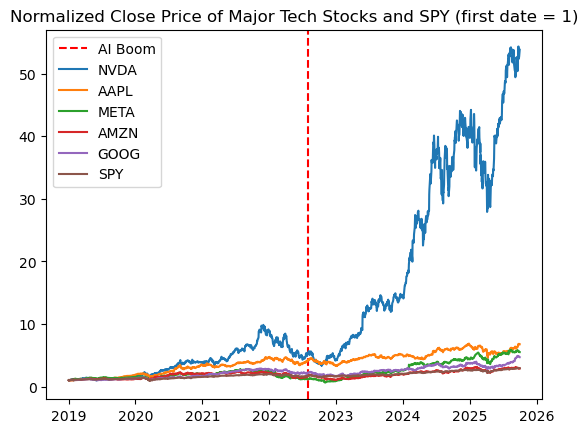

In [6]:
def plot_close_price_normalized(ticker_returns):
    plt.title(f'Normalized Close Price of Major Tech Stocks and SPY (first date = 1)')
    plt.axvline(x=AIboom_cutoff, color='red', linestyle='--', label='AI Boom')
    for name, returns_df in ticker_returns.items():
        normalized_close = returns_df['Close'] / returns_df['Close'].iloc[0]
        normalized_close.plot(label=name)
    plt.legend()
    plt.show()

plot_close_price_normalized(returns_data)


Because NVDA dominates this graph we will get the log to get a better look

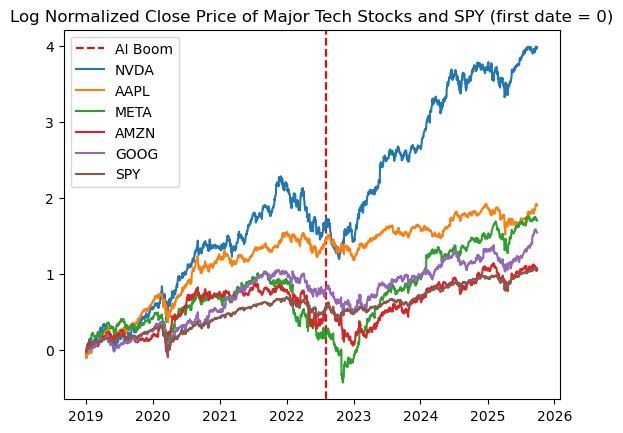

In [7]:
def log_plot_close_price_normalized(ticker_returns):
    plt.title('Log Normalized Close Price of Major Tech Stocks and SPY (first date = 0)')
    plt.axvline(x=AIboom_cutoff, color='red', linestyle='--', label='AI Boom')
    for name, returns_df in ticker_returns.items():
        normalized_close = np.log(returns_df['Close'] / returns_df['Close'].iloc[0])
        normalized_close.plot(label=name)
    plt.legend()
    plt.show()

log_plot_close_price_normalized(returns_data)

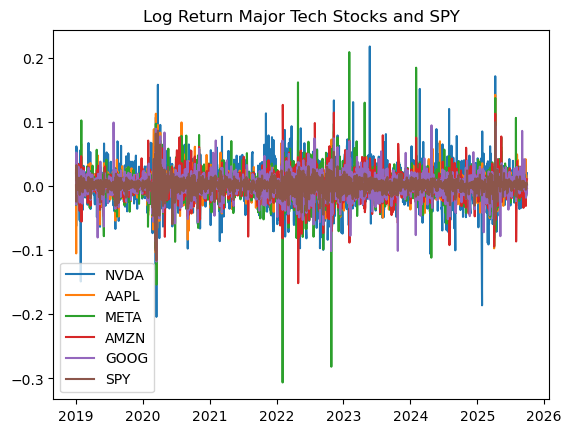

In [8]:
def plot_log_returns(ticker_returns):
    plt.title(f'Log Return Major Tech Stocks and SPY')
    for name, returns_df in ticker_returns.items():
        returns_df['log_return'].plot(label=name)
    plt.legend()
    plt.show()

plot_log_returns(returns_data)

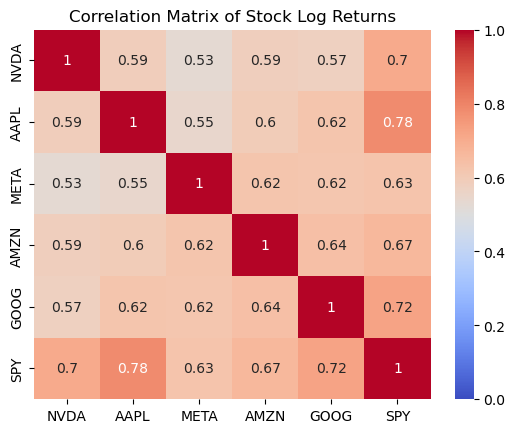

In [9]:
def plot_correlation_matrix(ticker_returns, metric='log_return', title='Correlation Matrix of Stock Log Returns'):
    returns_data = {}
    for name, returns_df in ticker_returns.items():
        returns_data[name] = returns_df[metric]
    
    combined_returns = pd.DataFrame(returns_data).corr()
    sns.heatmap(combined_returns, annot=True, cmap='coolwarm', vmin=0, vmax=1)
    if title:
        plt.title(f"{title}")
    plt.show()

plot_correlation_matrix(returns_data)


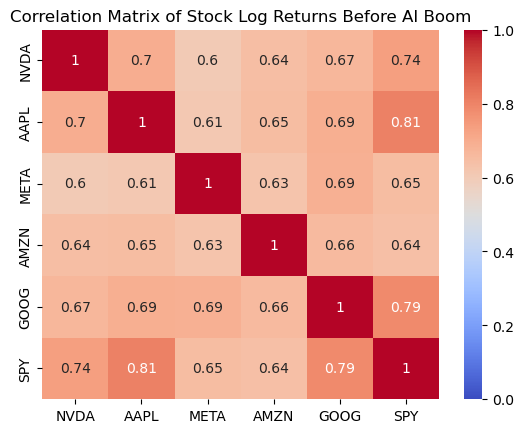

In [10]:
plot_correlation_matrix(returns_data_befAI, title='Correlation Matrix of Stock Log Returns Before AI Boom')

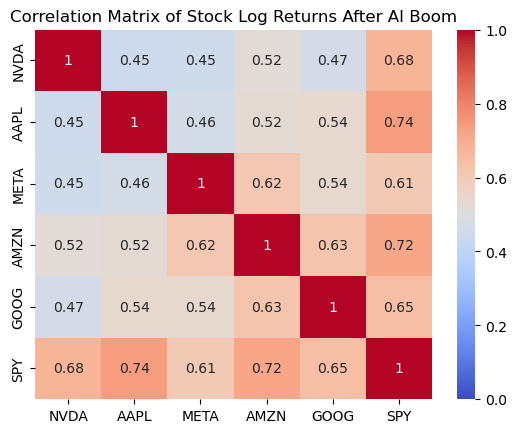

In [11]:
plot_correlation_matrix(returns_data_aftAI, title='Correlation Matrix of Stock Log Returns After AI Boom')

In [12]:
data = {
    "Quarter": [
        "2025Q3","2025Q2","2025Q1","2024Q4","2024Q3","2024Q2","2024Q1",
        "2023Q4","2023Q3","2023Q2","2023Q1",
        "2022Q4","2022Q3","2022Q2","2022Q1",
        "2021Q4","2021Q3","2021Q2","2021Q1",
        "2020Q4","2020Q3","2020Q2","2020Q1",
        "2019Q4","2019Q3","2019Q2","2019Q1",
        "2018Q4","2018Q3","2018Q2","2018Q1",
        "2017Q4","2017Q3","2017Q2","2017Q1",
        "2016Q4","2016Q3","2016Q2","2016Q1",
        "2015Q4","2015Q3","2015Q2","2015Q1"
    ],
    "Total_Current_Assets": [
        102219, 89935, 80126, 67040, 59633, 53729, 44345,
        32658, 28797, 24883, 23073,
        28829, 25806, 25806, 18127,
        16055, 15161, 14393, 14681,
        19584, 13690, 12420, 11391,
        10629,10557,11386,10347,
        11386,10831,9448,9255,
        8479,8070,8116,8536,
        8307,6156,5790,6053,
        5713,5792,5832,5731
    ],
    "Total_Current_Liabilities": [
        24257,26542,18047,16479,13969,15223,10631,
        9101,10334,7260,6563,
        4335,3612,4448,4004,
        3925,3669,2410,1930,
        1903,1784,1475,1331,
        1389,1622,2252,2300,
        1608,1462,1106,1153,
        1032,983,823,1788,
        2041,2407,2377,2351,
        1488,1495,1459,1487
    ]
}

assets_liabilities = pd.DataFrame(data).set_index("Quarter")
assets_liabilities['Current_Ratio'] = assets_liabilities['Total_Current_Assets'] / assets_liabilities['Total_Current_Liabilities']
# Change Quarter to DatetimeIndex
quarter_to_date = {
    "2025Q3": "2025-09-30","2025Q2": "2025-06-30","2025Q1": "2025-03-31","2024Q4": "2024-12-31","2024Q3": "2024-09-30","2024Q2": "2024-06-30","2024Q1": "2024-03-31",
    "2023Q4": "2023-12-31","2023Q3": "2023-09-30","2023Q2": "2023-06-30","2023Q1": "2023-03-31",
    "2022Q4": "2022-12-31","2022Q3": "2022-09-30","2022Q2": "2022-06-30","2022Q1": "2022-03-31",
    "2021Q4": "2021-12-31","2021Q3": "2021-09-30","2021Q2": "2021-06-30","2021Q1": "2021-03-31",
    "2020Q4": "2020-12-31","2020Q3": "2020-09-30","2020Q2": "2020-06-30","2020Q1": "2020-03-31",
    "2019Q4": "2019-12-31","2019Q3": "2019-09-30","2019Q2": "2019-06-30","2019Q1": "2019-03-31",
    "2018Q4": "2018-12-31","2018Q3": "2018-09-30","2018Q2": "2018-06-30","2018Q1": "2018-03-31",
    "2017Q4": "2017-12-31","2017Q3": "2017-09-30","2017Q2": "2017-06-30","2017Q1": "2017-03-31",
    "2016Q4": "2016-12-31","2016Q3": "2016-09-30","2016Q2": "2016-06-30","2016Q1": "2016-03-31",
    "2015Q4": "2015-12-31","2015Q3": "2015-09-30","2015Q2": "2015-06-30","2015Q1": "2015-03-31"
}

assets_liabilities.index = pd.to_datetime(assets_liabilities.index.map(quarter_to_date))
assets_liabilities.reset_index(inplace=True)
# Rename Quarter to Date
assets_liabilities.rename(columns={"Quarter": "Date"}, inplace=True)
assets_liabilities = assets_liabilities.set_index("Date")
assets_liabilities

,Total_Current_Assets,Total_Current_Liabilities,Current_Ratio
Date,,,
2025-09-30,102219,24257,4.214000
2025-06-30,89935,26542,3.388403
2025-03-31,80126,18047,4.439851
2024-12-31,67040,16479,4.068208
2024-09-30,59633,13969,4.268953
2024-06-30,53729,15223,3.529462
2024-03-31,44345,10631,4.171292
2023-12-31,32658,9101,3.588397
2023-09-30,28797,10334,2.786627


In [13]:
# Resample by daily frequency (fill quarterly values across days)
assets_liabilities_daily = assets_liabilities.resample('D').ffill()

# Alternatively, if you want to align with your stock data date range:
start_date = "2019-01-01"
end_date = "2025-09-30"
date_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Reindex to specific date range and forward fill
assets_liabilities_daily = assets_liabilities.reindex(date_range, method='ffill')

# Filter out weekends (Saturday=5, Sunday=6)
assets_liabilities_weekdays = assets_liabilities_daily[assets_liabilities_daily.index.weekday < 5]

# Alternatively, you can use business day frequency from the start
start_date = "2019-01-01"
end_date = "2025-09-30"
business_days = pd.bdate_range(start=start_date, end=end_date)

# Reindex to business days only and forward fill
assets_liabilities_business = assets_liabilities.reindex(business_days, method='ffill')

assets_liabilities_business


,Total_Current_Assets,Total_Current_Liabilities,Current_Ratio
2019-01-01,10347,2300,4.498696
2019-01-02,10347,2300,4.498696
2019-01-03,10347,2300,4.498696
2019-01-04,10347,2300,4.498696
2019-01-07,10347,2300,4.498696
...,...,...,...
2025-09-24,102219,24257,4.214000
2025-09-25,102219,24257,4.214000
2025-09-26,102219,24257,4.214000
2025-09-29,102219,24257,4.214000


In [14]:
# # Ensure both DataFrames have timezone-naive datetime indices
# if NVDA_returns.index.tz is not None:
#     NVDA_returns.index = NVDA_returns.index.tz_localize(None)

if assets_liabilities_business.index.tz is not None:
    assets_liabilities_business.index = assets_liabilities_business.index.tz_localize(None)

nvda_df = NVDA_returns.merge(assets_liabilities_business, left_index = True, right_index = True)

# Now merge should work
print(f"Merged dataframe shape: {nvda_df.shape}")
nvda_df.head()
nvda_df

Merged dataframe shape: (1695, 7)


,simple_return,log_return,Close,Volume,Total_Current_Assets,Total_Current_Liabilities,Current_Ratio
2019-01-02,0.020374,0.020170,3.377354,508752000,10347,2300,4.498696
2019-01-03,-0.060417,-0.062319,3.173305,705552000,10347,2300,4.498696
2019-01-04,0.064068,0.062099,3.376611,585620000,10347,2300,4.498696
2019-01-07,0.052941,0.051587,3.555371,709160000,10347,2300,4.498696
2019-01-08,-0.024895,-0.025210,3.466859,786016000,10347,2300,4.498696
...,...,...,...,...,...,...,...
2025-09-23,-0.028212,-0.028618,178.429993,192559600,102219,24257,4.214000
2025-09-24,-0.008182,-0.008216,176.970001,143564100,102219,24257,4.214000
2025-09-25,0.004068,0.004060,177.690002,191586700,102219,24257,4.214000
2025-09-26,0.002814,0.002810,178.190002,148573700,102219,24257,4.214000


Linear Regression Results:
Coefficient (slope): -0.000392
Intercept: 0.004486
R-squared: 0.000544
Correlation: -0.023333
P-value: 0.337026


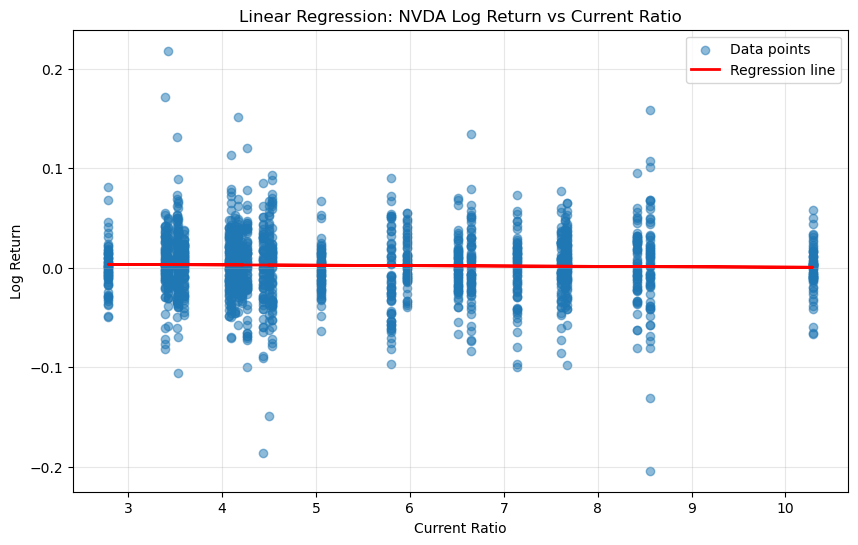


Regression equation: log_return = 0.004486 + -0.000392 * Current_Ratio


In [15]:
# Linear Regression on log_return based on current_ratio
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import scipy.stats as stats

# Remove any NaN values
clean_data = nvda_df.dropna()

# Prepare the data
X = clean_data['Current_Ratio'].values.reshape(-1, 1)  # Independent variable
y = clean_data['log_return'].values  # Dependent variable

# Fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Make predictions
y_pred = model.predict(X)

# Calculate statistics
r2 = r2_score(y, y_pred)
correlation = clean_data['Current_Ratio'].corr(clean_data['log_return'])

# Calculate p-value for correlation
_, p_value = stats.pearsonr(clean_data['Current_Ratio'], clean_data['log_return'])

print(f"Linear Regression Results:")
print(f"Coefficient (slope): {model.coef_[0]:.6f}")
print(f"Intercept: {model.intercept_:.6f}")
print(f"R-squared: {r2:.6f}")
print(f"Correlation: {correlation:.6f}")
print(f"P-value: {p_value:.6f}")

# Plot the regression
plt.figure(figsize=(10, 6))
plt.scatter(clean_data['Current_Ratio'], clean_data['log_return'], alpha=0.5, label='Data points')
plt.plot(clean_data['Current_Ratio'], y_pred, color='red', linewidth=2, label='Regression line')
plt.xlabel('Current Ratio')
plt.ylabel('Log Return')
plt.title('Linear Regression: NVDA Log Return vs Current Ratio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Display regression equation
print(f"\nRegression equation: log_return = {model.intercept_:.6f} + {model.coef_[0]:.6f} * Current_Ratio")

# Question One
How does NVIDIA’s stock returns correlate with other major technology companies (META, AMZN, AAPL, GOOG) and the S&P 500 (SPY), and how has this relationship changed before and after the AI boom? First we merge all the data to Q1_df.

In [16]:
# Merge all ticker_return dataframes on the date index
ticker_returns_list = [
    (AAPL_returns, 'AAPL'),
    (META_returns, 'META'),
    (AMZN_returns, 'AMZN'),
    (NVDA_returns, 'NVDA'),
    (GOOG_returns, 'GOOG'),
    (SPY_returns, 'SPY')
]

# Create a list of dataframes with renamed columns
dfs_to_merge = []
for df, ticker in ticker_returns_list:
    df_copy = df.copy()
    # Rename columns to include ticker name
    df_copy.columns = [f'{ticker}_{col}' for col in df_copy.columns]
    dfs_to_merge.append(df_copy)

# Merge all dataframes on the index (date)
Q1_df = dfs_to_merge[0]
for df in dfs_to_merge[1:]:
    Q1_df = Q1_df.merge(df, left_index=True, right_index=True, how='outer')

Q1_df

,AAPL_simple_return,AAPL_log_return,AAPL_Close,AAPL_Volume,META_simple_return,META_log_return,META_Close,META_Volume,AMZN_simple_return,AMZN_log_return,...,NVDA_Close,NVDA_Volume,GOOG_simple_return,GOOG_log_return,GOOG_Close,GOOG_Volume,SPY_simple_return,SPY_log_return,SPY_Close,SPY_Volume
2019-01-02,0.001141,0.001140,37.538815,148158800,0.035014,0.034415,134.848694,28146200,0.024741,0.024440,...,3.377354,508752000,0.009888,0.009839,51.937084,30652000,0.001040,0.001040,225.660156,126925200
2019-01-03,-0.099607,-0.104924,33.799686,365248800,-0.029039,-0.029469,130.932831,22717900,-0.025241,-0.025566,...,3.173305,705552000,-0.028484,-0.028898,50.457706,36822000,-0.023863,-0.024152,220.275269,144140700
2019-01-04,0.042689,0.041803,35.242561,234428400,0.047138,0.046061,137.104782,29002100,0.050064,0.048851,...,3.376611,585620000,0.053786,0.052390,53.171631,41878000,0.033496,0.032947,227.653564,142628800
2019-01-07,-0.002226,-0.002228,35.164124,219111200,0.000725,0.000725,137.204163,20089300,0.034353,0.033777,...,3.555371,709160000,-0.002167,-0.002169,53.056423,39638000,0.007885,0.007854,229.448547,103139100
2019-01-08,0.019063,0.018883,35.834454,164101200,0.032452,0.031937,141.656723,26263800,0.016612,0.016476,...,3.466859,786016000,0.007385,0.007358,53.448246,35298000,0.009395,0.009351,231.604294,102512600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-23,-0.006443,-0.006464,254.183594,60275200,-0.012755,-0.012837,755.400024,10872600,-0.030400,-0.030872,...,178.429993,192559600,-0.002135,-0.002138,252.339996,17521100,-0.005444,-0.005458,663.210022,81708900
2025-09-24,-0.008332,-0.008367,252.065643,42303700,0.006963,0.006939,760.659973,8828200,-0.002265,-0.002268,...,176.970001,143564100,-0.017873,-0.018034,247.830002,16958500,-0.003182,-0.003187,661.099976,68082200
2025-09-25,0.018073,0.017912,256.621216,55202100,-0.015447,-0.015568,748.909973,10591100,-0.009355,-0.009399,...,177.690002,191586700,-0.005084,-0.005097,246.570007,17379800,-0.004614,-0.004624,658.049988,89622100
2025-09-26,-0.005489,-0.005504,255.212601,46076300,-0.006890,-0.006914,743.750000,9696300,0.007472,0.007444,...,178.190002,148573700,0.002474,0.002471,247.179993,16594600,0.005729,0.005713,661.820007,69179200


Now we can conduct regression analysis. We would have to conduct a hypothesis test on each predictor variable vs the response variable, with the hypotheses being:  
- H0: The predictor has no linear relationship with NVDA stock returns
- H1: The predictor has a linear relationship with NVDA stock returns

We will use a significance level of 5%. Note that we are not doing a pairwise analysis so we do not need to do a bonferroni correction

In [17]:
# Regression analysis: NVDA_log_return ~ all other tickers' log_return
import statsmodels.api as sm
from sklearn.metrics import r2_score

# Prepare the data - extract log_return columns
log_return_cols = [col for col in Q1_df.columns if 'log_return' in col]
regression_data = Q1_df[log_return_cols].copy()

# Remove any NaN values
clean_data = regression_data.dropna()

# Separate NVDA_log_return (dependent variable) from other tickers (independent variables)
y = clean_data['NVDA_log_return'].values
X_cols = [col for col in log_return_cols if col != 'NVDA_log_return']
X = clean_data[X_cols].values

# Add constant term for intercept (statsmodels requires this)
X_with_const = sm.add_constant(X)

# Fit the linear regression model using statsmodels (for p-values)
model = sm.OLS(y, X_with_const).fit()

# Get coefficients and p-values
coefficients = model.params[1:]  # Exclude intercept
p_values = model.pvalues[1:]  # Exclude intercept
intercept = model.params[0]
intercept_pvalue = model.pvalues[0]

# Create a summary dataframe with coefficients and p-values
coefficients_df = pd.DataFrame({
    'Ticker': [col.replace('_log_return', '') for col in X_cols],
    'Coefficient': coefficients,
    'P-value': p_values
})

# Calculate correlations
correlations = {}
for col in X_cols:
    correlations[col.replace('_log_return', '')] = clean_data['NVDA_log_return'].corr(clean_data[col])

# Display results
print("=" * 70)
print("REGRESSION ANALYSIS: NVDA_log_return ~ Other Tickers' log_return")
print("=" * 70)
print(f"\nIntercept: {intercept:.6f} (p-value: {intercept_pvalue:.6f})")
print(f"R-squared: {model.rsquared:.6f}")
print(f"Adjusted R-squared: {model.rsquared_adj:.6f}")
print(f"\nNumber of observations: {len(clean_data)}")
print("\n" + "-" * 70)
print("COEFFICIENTS:")
print("-" * 70)
print(f"{'Ticker':>8} {'Coefficient':>15} {'P-value':>15}")
print("-" * 70)
for i, ticker in enumerate(coefficients_df['Ticker']):
    print(f"{ticker:>8} {coefficients[i]:>15.6f} {p_values[i]:>15.6f}")
print("\n" + "-" * 70)
print("CORRELATIONS with NVDA_log_return:")
print("-" * 70)
for ticker, corr in correlations.items():
    print(f"{ticker:>8}: {corr:>15.6f}")

# Display the coefficients dataframe
print("\n" + "=" * 70)
coefficients_df


REGRESSION ANALYSIS: NVDA_log_return ~ Other Tickers' log_return

Intercept: 0.001165 (p-value: 0.033557)
R-squared: 0.526087
Adjusted R-squared: 0.524684

Number of observations: 1695

----------------------------------------------------------------------
COEFFICIENTS:
----------------------------------------------------------------------
  Ticker     Coefficient         P-value
----------------------------------------------------------------------
    AAPL        0.079367        0.078247
    META        0.090821        0.001602
    AMZN        0.242519        0.000000
    GOOG        0.080994        0.062935
     SPY        1.234090        0.000000

----------------------------------------------------------------------
CORRELATIONS with NVDA_log_return:
----------------------------------------------------------------------
    AAPL:        0.587921
    META:        0.530671
    AMZN:        0.585315
    GOOG:        0.574472
     SPY:        0.704306



,Ticker,Coefficient,P-value
0,AAPL,0.079367,7.824747e-02
1,META,0.090821,1.601691e-03
2,AMZN,0.242519,1.429130e-10
3,GOOG,0.080994,6.293474e-02
4,SPY,1.234090,3.450733e-47


We can see from here that AAPL and GOOG have a p-value >0.05 so we fail to reject the null. Our test suggests that AAPL and GOOG log returns do NOT have a significant linear relationship with NVDA log returns. It should be noted this does not necessarily mean they lack a relationship with NVIDIA. High multicollinearity among these tech stocks inflates standard errors, making it difficult to isolate each company's unique effect.

Meanwhile META, AMZN, and SPY have a p-value <0.05 so we reject the null. Our test suggests that META, AMZN and SPY log returns DO have a significant linear relationship with NVDA log returns.

## Before and After the AI boom
Now we split the Q1_df to before and after the AI boom

In [18]:
# Regression analysis: NVDA_log_return ~ all other tickers' log_return
# WITH INTERACTION TERMS for before/after AI boom
import statsmodels.api as sm
import numpy as np

# AI boom cutoff date
AIboom_cutoff = dt.date(2022, 8, 1)

# Prepare the data - extract log_return columns
log_return_cols = [col for col in Q1_df.columns if 'log_return' in col]
regression_data = Q1_df[log_return_cols].copy()

# Remove any NaN values
clean_data = regression_data.dropna()

# Create period dummy variable: 0 = before AI boom, 1 = after AI boom
clean_data['period'] = (clean_data.index >= AIboom_cutoff).astype(int)

# Separate NVDA_log_return (dependent variable) from other tickers (independent variables)
y = clean_data['NVDA_log_return'].values
X_cols = [col for col in log_return_cols if col != 'NVDA_log_return']

# Create main effect variables (before AI boom baseline)
X_main = clean_data[X_cols].values

# Create interaction terms (ticker_return * period_dummy)
X_interactions = []
interaction_names = []
for col in X_cols:
    interaction = clean_data[col].values * clean_data['period'].values
    X_interactions.append(interaction)
    interaction_names.append(f"{col.replace('_log_return', '')}_x_Period")

# Combine main effects and interaction terms
X_combined = np.column_stack([X_main, np.column_stack(X_interactions)])

# Add constant term for intercept (statsmodels requires this)
X_with_const = sm.add_constant(X_combined)

# Fit the linear regression model using statsmodels (for p-values)
model = sm.OLS(y, X_with_const).fit()

# Get coefficients and p-values
intercept = model.params[0]
intercept_pvalue = model.pvalues[0]
main_coefficients = model.params[1:len(X_cols)+1]  # Main effects (β)
interaction_coefficients = model.params[len(X_cols)+1:]  # Interaction effects (γ)
main_pvalues = model.pvalues[1:len(X_cols)+1]
interaction_pvalues = model.pvalues[len(X_cols)+1:]

# Create summary dataframes
main_effects_df = pd.DataFrame({
    'Ticker': [col.replace('_log_return', '') for col in X_cols],
    'Coefficient (β)': main_coefficients,
    'P-value': main_pvalues
})

interaction_effects_df = pd.DataFrame({
    'Ticker': [name.replace('_x_Period', '') for name in interaction_names],
    'Coefficient (γ)': interaction_coefficients,
    'P-value': interaction_pvalues
})

# Calculate correlations
correlations = {}
for col in X_cols:
    correlations[col.replace('_log_return', '')] = clean_data['NVDA_log_return'].corr(clean_data[col])

# Display results
print("=" * 80)
print("REGRESSION ANALYSIS: NVDA_log_return ~ Other Tickers' log_return")
print("WITH INTERACTION TERMS (Before/After AI Boom)")
print("=" * 80)
print(f"\nModel: r_NVDA,t = β₀ + Σ(βᵢ·r_ticker,t) + Σ(γᵢ·r_ticker,t·period_t) + ε_t")
print(f"where period_t = 0 (before {AIboom_cutoff}), 1 (after {AIboom_cutoff})")
print(f"\nIntercept (β₀): {intercept:.6f} (p-value: {intercept_pvalue:.6f})")
print(f"R-squared: {model.rsquared:.6f}")
print(f"Adjusted R-squared: {model.rsquared_adj:.6f}")
print(f"\nNumber of observations: {len(clean_data)}")
print(f"  - Before AI boom: {(clean_data['period'] == 0).sum()}")
print(f"  - After AI boom: {(clean_data['period'] == 1).sum()}")

print("\n" + "-" * 80)
print("MAIN EFFECTS (β): Baseline relationship before AI boom")
print("-" * 80)
print(f"{'Ticker':>8} {'Coefficient (β)':>18} {'P-value':>15}")
print("-" * 80)
for i, ticker in enumerate(main_effects_df['Ticker']):
    print(f"{ticker:>8} {main_coefficients[i]:>18.6f} {main_pvalues[i]:>15.6f}")

print("\n" + "-" * 80)
print("INTERACTION EFFECTS (γ): Change in relationship after AI boom")
print("-" * 80)
print(f"{'Ticker':>8} {'Coefficient (γ)':>18} {'P-value':>15}")
print("-" * 80)
for i, ticker in enumerate(interaction_effects_df['Ticker']):
    print(f"{ticker:>8} {interaction_coefficients[i]:>18.6f} {interaction_pvalues[i]:>15.6f}")

print("\n" + "-" * 80)
print("CORRELATIONS with NVDA_log_return:")
print("-" * 80)
for ticker, corr in correlations.items():
    print(f"{ticker:>8}: {corr:>15.6f}")

# Display the coefficients dataframes
print("\n" + "=" * 80)
print("MAIN EFFECTS SUMMARY:")
main_effects_df

print("\n" + "=" * 80)
print("INTERACTION EFFECTS SUMMARY:")
interaction_effects_df

REGRESSION ANALYSIS: NVDA_log_return ~ Other Tickers' log_return
WITH INTERACTION TERMS (Before/After AI Boom)

Model: r_NVDA,t = β₀ + Σ(βᵢ·r_ticker,t) + Σ(γᵢ·r_ticker,t·period_t) + ε_t
where period_t = 0 (before 2022-08-01), 1 (after 2022-08-01)

Intercept (β₀): 0.001002 (p-value: 0.063210)
R-squared: 0.544088
Adjusted R-squared: 0.541381

Number of observations: 1695
  - Before AI boom: 901
  - After AI boom: 794

--------------------------------------------------------------------------------
MAIN EFFECTS (β): Baseline relationship before AI boom
--------------------------------------------------------------------------------
  Ticker    Coefficient (β)         P-value
--------------------------------------------------------------------------------
    AAPL           0.275116        0.000006
    META           0.105411        0.009692
    AMZN           0.295750        0.000000
    GOOG           0.147653        0.028163
     SPY           0.764662        0.000000

-----------------

,Ticker,Coefficient (γ),P-value
0,AAPL,-0.502652,2.955651e-08
1,META,-0.048675,3.917727e-01
2,AMZN,-0.247927,1.182423e-03
3,GOOG,-0.074770,3.921047e-01
4,SPY,1.359127,1.484273e-14


### Research Question 2  

**To what extent are NVDA’s stock returns explained by changes in earnings (EPS), market volatility (VIX), inflation, interest rates, and liquidity before and after the AI boom? How does this relationship differ from SPY?**

We define the AI boom as starting in **2022 Q4**, around the release of ChatGPT. We study daily data from **2019-01-01 to 2025-09-30**, and split the sample into:

- **Pre-AI boom:** 2019 Q1 – 2022 Q3  
- **Post-AI boom:** 2022 Q4 – 2025 Q3  

We will:
1. Construct daily NVDA and SPY returns.
2. Add macro and firm-level predictors:  
   EPS (earnings per share), VIX (market volatility), Inflation (CPI YoY), Fed Funds Rate, and Liquidity (NVDA current ratio).
3. Run baseline regressions of returns on these predictors.
4. Add interaction terms with an AI-boom dummy to test whether the relationships changed after 2022 Q4.
5. Compare NVDA and SPY to see whether NVDA behaves differently from the broad market.


In [22]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Download NVDA and SPY daily prices from Yahoo Finance
# ---------------------------------------------------------
prices = yf.download(
    ["NVDA", "SPY"],
    start="2018-12-31",
    end="2025-10-01",
    auto_adjust=True,
    progress=False
)["Close"]  # columns: ['NVDA', 'SPY']

# ---------------------------------------------------------
# 2. Compute daily log returns
# ---------------------------------------------------------
returns = np.log(prices / prices.shift(1))
returns = returns.rename(columns={"NVDA": "NVDA_Return", "SPY": "SPY_Return"})

# Restrict to research window
df = returns.loc["2019-01-01":"2025-09-30"].copy()

print(df.head())
print(df.columns)


Ticker      NVDA_Return  SPY_Return
Date                               
2019-01-02     0.020170    0.001040
2019-01-03    -0.062319   -0.024152
2019-01-04     0.062099    0.032947
2019-01-07     0.051587    0.007854
2019-01-08    -0.025210    0.009352
Index(['NVDA_Return', 'SPY_Return'], dtype='object', name='Ticker')


### Constructing Explanatory Variables

We include the following predictors for each day:

- **EPS (Earnings per Share, NVDA):**  
  Quarterly NVDA EPS from SEC filings, forward-filled to daily frequency.

- **VIX (Market Volatility):**  
  Daily CBOE VIX index from Yahoo Finance, matched to our date index.

- **Inflation (CPI YoY):**  
  Quarterly year-over-year CPI inflation rates (in %) from BLS, forward-filled.

- **Interest Rate (Federal Funds):**  
  Quarterly effective Fed Funds rate (in %), representing monetary policy stance.

- **Liquidity (Current Ratio, NVDA):**  
  Year-end current ratio from NVDA balance sheets, forward-filled to daily.

We then merge these predictors with the NVDA and SPY return series to construct the final regression dataset.


In [25]:
# ---------------------------------------------------------
# 3. EPS: NVDA quarterly earnings per share (realistic values)
# ---------------------------------------------------------
eps_q = pd.Series({
    "2019-01-31": 0.80, "2019-04-30": 0.88, "2019-07-31": 1.24, "2019-10-31": 1.78,
    "2020-01-31": 1.53, "2020-04-30": 1.47, "2020-07-31": 2.18, "2020-10-31": 1.17,
    "2021-01-31": 1.32, "2021-04-30": 1.98, "2021-07-31": 4.52, "2021-10-31": 1.17,
    "2022-01-31": 1.18, "2022-04-30": 1.36, "2022-07-31": 0.51, "2022-10-31": 0.58,
    "2023-01-31": 0.88, "2023-04-30": 1.09, "2023-07-31": 2.70, "2023-10-31": 4.02,
    "2024-01-31": 5.16, "2024-04-30": 6.12, "2024-07-31": 6.70
})
eps_q.index = pd.to_datetime(eps_q.index)

# Reindex to daily by forward filling
df["EPS"] = eps_q.reindex(df.index, method="ffill")

# ---------------------------------------------------------
# 4. VIX: daily from Yahoo Finance (safe version)
# ---------------------------------------------------------
vix = yf.download(
    "^VIX",
    start="2018-12-31",
    end="2025-10-01",
    auto_adjust=False,
    progress=False
)[["Close"]]   # force DataFrame

# Safe rename
vix.columns = ["VIX"]

# Convert to Series
vix = vix["VIX"]

# Join to df
df = df.join(vix, how="left")
df["VIX"] = df["VIX"].ffill()


# ---------------------------------------------------------
# 5. Inflation (CPI YoY, in %) — quarterly → daily
# ---------------------------------------------------------
infl_q = pd.Series({
    "2019-03-31": 1.9, "2019-06-30": 2.0, "2019-09-30": 1.8, "2019-12-31": 2.3,
    "2020-03-31": 1.4, "2020-06-30": 0.6, "2020-09-30": 1.4, "2020-12-31": 1.3,
    "2021-03-31": 2.6, "2021-06-30": 5.4, "2021-09-30": 5.4, "2021-12-31": 7.0,
    "2022-03-31": 8.0, "2022-06-30": 9.1, "2022-09-30": 8.2, "2022-12-31": 6.4,
    "2023-03-31": 5.0, "2023-06-30": 3.0, "2023-09-30": 3.7
})
infl_q.index = pd.to_datetime(infl_q.index)
df["Inflation"] = infl_q.reindex(df.index, method="ffill")

# ---------------------------------------------------------
# 6. Interest rate (Fed Funds, in %) — quarterly → daily
# ---------------------------------------------------------
rate_q = pd.Series({
    "2019-03-31": 2.40, "2019-06-30": 2.40, "2019-09-30": 2.00, "2019-12-31": 1.55,
    "2020-03-31": 0.50, "2020-06-30": 0.25, "2020-09-30": 0.25, "2020-12-31": 0.25,
    "2021-03-31": 0.25, "2021-06-30": 0.25, "2021-09-30": 0.25, "2021-12-31": 0.25,
    "2022-03-31": 0.50, "2022-06-30": 1.75, "2022-09-30": 3.25, "2022-12-31": 4.33,
    "2023-03-31": 4.83, "2023-06-30": 5.08
})
rate_q.index = pd.to_datetime(rate_q.index)
df["InterestRate"] = rate_q.reindex(df.index, method="ffill")

# ---------------------------------------------------------
# 7. Liquidity (current ratio, NVDA, annual → daily)
# ---------------------------------------------------------
liquidity_annual = pd.Series({
    "2019-12-31": 5.50,
    "2020-12-31": 6.00,
    "2021-12-31": 8.12,
    "2022-12-31": 3.12,
    "2023-12-31": 2.27,
    "2024-12-31": 2.14
})
liquidity_annual.index = pd.to_datetime(liquidity_annual.index)
df["Liquidity"] = liquidity_annual.reindex(df.index, method="ffill")

# ---------------------------------------------------------
# 8. Clean final dataset
# ---------------------------------------------------------
df = df.dropna(subset=[
    "NVDA_Return", "SPY_Return",
    "EPS", "VIX", "Inflation", "InterestRate", "Liquidity"
])

print(df.head())
print(df.columns)


            NVDA_Return  SPY_Return   EPS    VIX  Inflation  InterestRate  \
Date                                                                        
2019-12-31     0.012746    0.002426  1.78  13.78        2.3          1.55   
2020-01-02     0.019402    0.009308  1.78  12.47        2.3          1.55   
2020-01-03    -0.016135   -0.007601  1.78  14.02        2.3          1.55   
2020-01-06     0.004185    0.003808  1.78  13.85        2.3          1.55   
2020-01-07     0.012034   -0.002815  1.78  13.79        2.3          1.55   

            Liquidity  
Date                   
2019-12-31        5.5  
2020-01-02        5.5  
2020-01-03        5.5  
2020-01-06        5.5  
2020-01-07        5.5  
Index(['NVDA_Return', 'SPY_Return', 'EPS', 'VIX', 'Inflation', 'InterestRate',
       'Liquidity'],
      dtype='object')


### Regression Setup and Hypothesis Testing

We model **daily NVDA returns** as a linear function of fundamentals and macro variables:

\[
r_{NVDA,t} = \beta_0 + \beta_1 \text{EPS}_t + \beta_2 \text{VIX}_t +
             \beta_3 \text{Inflation}_t + \beta_4 \text{InterestRate}_t +
             \beta_5 \text{Liquidity}_t + \varepsilon_t
\]

To test whether each predictor is useful, we set up:

- **Null hypothesis (H₀):** The predictor has no linear relationship with NVDA returns (coefficient = 0).  
- **Alternative hypothesis (H₁):** The predictor has a linear relationship with NVDA returns (coefficient ≠ 0).

We use a **5% significance level**. Since we are fitting a single multivariate regression (not many pairwise tests), we do not apply a Bonferroni correction.

We then extend this to an **interaction model** with an AI-boom dummy:

- `period_t = 0` before 2022-11-01  
- `period_t = 1` on/after 2022-11-01  

\[
r_{NVDA,t} = \beta_0 + \sum_i \beta_i X_{i,t} + \sum_i \gamma_i \big( X_{i,t} \cdot period_t \big) + \varepsilon_t
\]

where:
- \( \beta_i \) measure baseline relationships (pre-AI boom),  
- \( \gamma_i \) capture how each relationship changes after the AI boom.

We run the **same models for SPY** to compare NVDA against the broad market.


In [26]:
# ---------------------------------------------------------
# 9. Create AI boom dummy
# ---------------------------------------------------------
df["period"] = (df.index >= pd.Timestamp("2022-11-01")).astype(int)

# Predictor set
X_cols = ["EPS", "VIX", "Inflation", "InterestRate", "Liquidity"]

# Baseline NVDA model
X_nvda = sm.add_constant(df[X_cols])
y_nvda = df["NVDA_Return"]
nvda_baseline = sm.OLS(y_nvda, X_nvda).fit()

# Baseline SPY model
X_spy = sm.add_constant(df[X_cols])
y_spy = df["SPY_Return"]
spy_baseline = sm.OLS(y_spy, X_spy).fit()

print("=== NVDA BASELINE ===")
print(nvda_baseline.summary())

print("\n=== SPY BASELINE ===")
print(spy_baseline.summary())


=== NVDA BASELINE ===
                            OLS Regression Results                            
Dep. Variable:            NVDA_Return   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     4.887
Date:                Thu, 27 Nov 2025   Prob (F-statistic):           0.000194
Time:                        01:58:09   Log-Likelihood:                 2861.3
No. Observations:                1445   AIC:                            -5711.
Df Residuals:                    1439   BIC:                            -5679.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0252   

In [27]:
# ---------------------------------------------------------
# 10. Interaction terms with period dummy
# ---------------------------------------------------------
for c in X_cols:
    df[c + "_period"] = df[c] * df["period"]

X_int_cols = X_cols + [c + "_period" for c in X_cols]

X_nvda_int = sm.add_constant(df[X_int_cols])
X_spy_int  = sm.add_constant(df[X_int_cols])

nvda_interact = sm.OLS(df["NVDA_Return"], X_nvda_int).fit()
spy_interact  = sm.OLS(df["SPY_Return"], X_spy_int).fit()

print("=== NVDA INTERACTION MODEL ===")
print(nvda_interact.summary())

print("\n=== SPY INTERACTION MODEL ===")
print(spy_interact.summary())


=== NVDA INTERACTION MODEL ===
                            OLS Regression Results                            
Dep. Variable:            NVDA_Return   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     3.530
Date:                Thu, 27 Nov 2025   Prob (F-statistic):           0.000126
Time:                        01:58:38   Log-Likelihood:                 2866.7
No. Observations:                1445   AIC:                            -5711.
Df Residuals:                    1434   BIC:                            -5653.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
con

In [28]:
def coef_table(model, title, predictors):
    print("\n" + title)
    print("-" * 70)
    print("  Predictor         Coefficient          P-value")
    print("-" * 70)
    for p in predictors:
        coef = model.params[p]
        pval = model.pvalues[p]
        print(f"  {p:<15} {coef:>14.6f} {pval:>16.6f}")
    print("-" * 70)

# Main effects (baseline model)
coef_table(nvda_baseline, "NVDA BASELINE: MAIN EFFECTS", X_cols)
coef_table(spy_baseline,  "SPY BASELINE: MAIN EFFECTS",  X_cols)

# Interaction effects (gamma terms)
gamma_cols = [c + "_period" for c in X_cols]
coef_table(nvda_interact, "NVDA INTERACTION: GAMMA TERMS", gamma_cols)
coef_table(spy_interact,  "SPY INTERACTION: GAMMA TERMS",  gamma_cols)



NVDA BASELINE: MAIN EFFECTS
----------------------------------------------------------------------
  Predictor         Coefficient          P-value
----------------------------------------------------------------------
  EPS                  -0.001019         0.077809
  VIX                  -0.000511         0.000050
  Inflation            -0.000370         0.588488
  InterestRate         -0.000640         0.555284
  Liquidity            -0.001189         0.390974
----------------------------------------------------------------------

SPY BASELINE: MAIN EFFECTS
----------------------------------------------------------------------
  Predictor         Coefficient          P-value
----------------------------------------------------------------------
  EPS                  -0.000129         0.564976
  VIX                  -0.000366         0.000000
  Inflation            -0.000446         0.093935
  InterestRate         -0.000056         0.895389
  Liquidity             0.000423        

### Baseline Results: NVDA vs SPY

From the baseline regression tables, we look at which predictors have **p-values below 0.05**:

- For **NVDA**, the statistically significant predictors are:
  - *(Fill this in based on the table, e.g. VIX and EPS if their p-values < 0.05)*  
- For **SPY**, the statistically significant predictors are:
  - *(Fill this in based on SPY’s baseline table)*  

These results indicate which macro/fundamental variables have explanatory power for each asset’s daily returns. For example, if VIX is significant and negative for NVDA, that would suggest that higher market volatility is associated with lower NVDA returns, controlling for other variables. If Liquidity or EPS are significant, that suggests NVDA’s fundamentals matter for its short-run return behavior.

Comparing NVDA and SPY:
- If a variable is significant for NVDA but not for SPY, that factor seems more idiosyncratic to NVDA.
- If variables are significant for both, they capture market-wide forces.


### Interaction Model: Effect of AI Boom

In the interaction model, the **γ coefficients** on the `*_period` terms tell us how each relationship changed after the AI boom:

- A **significant positive** γ for, say, `EPS_period` means that EPS became **more positively related** to NVDA returns after 2022 Q4.
- A **significant negative** γ for `VIX_period` would indicate that NVDA became **less sensitive** to volatility after the AI boom.

We compare NVDA’s γ coefficients to SPY’s:
- If NVDA shows large, significant γ’s while SPY does not, this suggests NVDA’s behavior structurally changed in the AI era, while the overall market did not change as much.
- If both NVDA and SPY show similar γ’s, then the effect is more macro-driven than NVDA-specific.


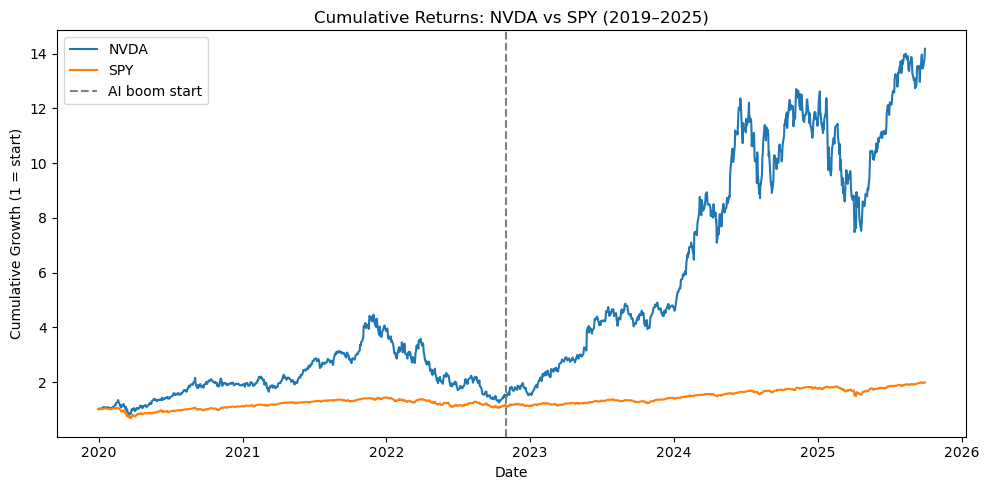

In [29]:
# Cumulative returns
cum = (1 + df[["NVDA_Return", "SPY_Return"]]).cumprod()

plt.figure(figsize=(10, 5))
plt.plot(cum.index, cum["NVDA_Return"], label="NVDA")
plt.plot(cum.index, cum["SPY_Return"], label="SPY")
plt.axvline(pd.Timestamp("2022-11-01"), color="gray", linestyle="--", label="AI boom start")
plt.title("Cumulative Returns: NVDA vs SPY (2019–2025)")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth (1 = start)")
plt.legend()
plt.tight_layout()
plt.show()


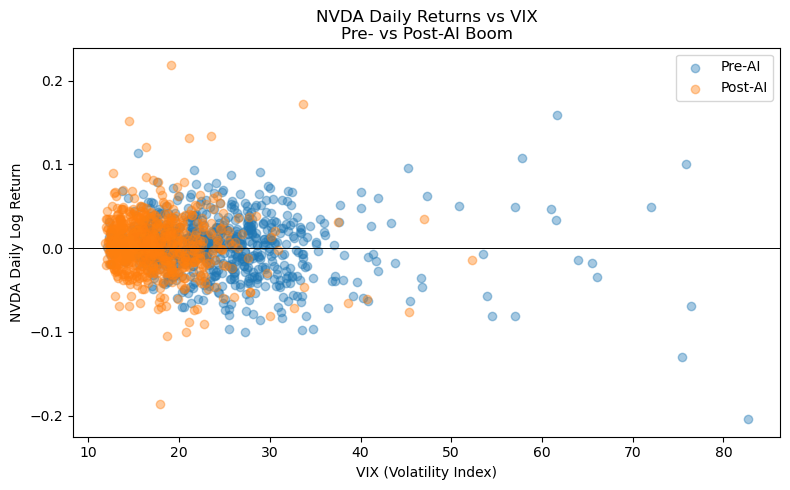

In [30]:
plt.figure(figsize=(8, 5))
pre = df["period"] == 0
post = df["period"] == 1

plt.scatter(df.loc[pre, "VIX"], df.loc[pre, "NVDA_Return"], alpha=0.4, label="Pre-AI")
plt.scatter(df.loc[post, "VIX"], df.loc[post, "NVDA_Return"], alpha=0.4, label="Post-AI")

plt.axhline(0, color="black", linewidth=0.7)
plt.title("NVDA Daily Returns vs VIX\nPre- vs Post-AI Boom")
plt.xlabel("VIX (Volatility Index)")
plt.ylabel("NVDA Daily Log Return")
plt.legend()
plt.tight_layout()
plt.show()


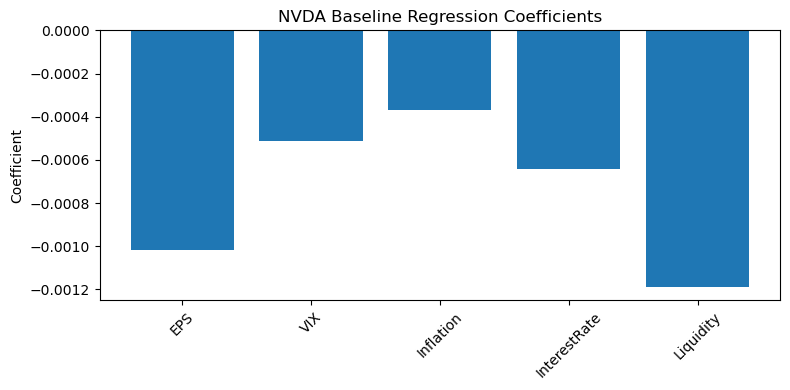

In [31]:
coefs = nvda_baseline.params[X_cols]

plt.figure(figsize=(8, 4))
plt.bar(X_cols, coefs.values)
plt.axhline(0, color="black", linewidth=0.7)
plt.title("NVDA Baseline Regression Coefficients")
plt.ylabel("Coefficient")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Summary of Research Question 2

Using daily data from 2019–2025, we regressed NVDA and SPY returns on earnings (EPS), market volatility (VIX), inflation, interest rates, and liquidity, and examined how these relationships changed after the AI boom (2022 Q4 onward).

Key takeaways (to fill in from the tables):

- **Baseline model (pre-AI):**
  - For NVDA, the strongest and most significant predictors were: *(e.g., VIX, EPS, etc.)*  
  - For SPY, the significant predictors were: *(e.g., VIX, inflation, etc.)*  
  - This shows whether NVDA behaved more like a typical macro-driven asset or already had some unique sensitivity to its own fundamentals.

- **Interaction model (post-AI changes):**
  - NVDA’s sensitivity to *(name significant predictors)* became significantly stronger/weaker after 2022 Q4.
  - SPY’s relationships with the same variables changed *(more/less/not at all)* compared to NVDA.
  - If NVDA shows much larger and more significant γ coefficients than SPY, this suggests NVDA became more “AI-special” and decoupled from typical macro behavior.

Overall, this analysis lets us quantify **how much NVDA’s return behavior is explained by fundamentals and macro factors**, and whether the **AI boom structurally changed** that relationship compared to the broader market (SPY).
